In [1]:
import requests
import json

# URL 문자열
url ='https://apihub.kma.go.kr/api/typ01/url/kma_sfctm2.php?tm=202211300900&stn=0&help=1&authKey=6XEt4XIFQJCxLeFyBYCQjg'

# GET 요청
response = requests.get(url)

# 응답을 JSON 형태로 변환
json_response = response.text

print(json_response)

#START7777
#--------------------------------------------------------------------------------------------------
#  기상청 지상관측 시간자료 [입력인수형태][예] ?tm=201007151200&stn=0&help=1
#--------------------------------------------------------------------------------------------------
#  1. TM     : 관측시각 (KST)
#  2. STN    : 국내 지점번호
#  3. WD     : 풍향 (36방위)
#  4. WS     : 풍속 (m/s)
#  5. GST_WD : 돌풍향 (36방위)
#  6. GST_WS : 돌풍속 (m/s)
#  7. GST_TM : 돌풍속이 관측된 시각 (시분)
#  8. PA     : 현지기압 (hPa)
#  9. PS     : 해면기압 (hPa)
# 10. PT     : 기압변화경향 (Code 0200) 
# 11. PR     : 기압변화량 (hPa)
# 12. TA     : 기온 (C)
# 13. TD     : 이슬점온도 (C)
# 14. HM     : 상대습도 (%)
# 15. PV     : 수증기압 (hPa)
# 16. RN     : 강수량 (mm) : 11월~다음해3월까지는 3시간강수량(3,6,...24시 이외는 자료없음으로 표출), 4~10월까지는 1시간 강수량
# 17. RN_DAY : 일강수량 (mm) : 해당시간까지 관측된 양(통계표)
# 18. RN_JUN : 일강수량 (mm) : 해당시간까지 관측된 양을 전문으로 입력한 값(전문)
# 19. RN_INT : 강수강도 (mm/h) : 관측하는 곳이 별로 없음
# 20. SD_HR3 : 3시간 신적설 (cm) : 3시간 동안 내린 신적설의 높이
# 21. SD_DAY : 일 신적설 (cm) : 00시00분부터 위 관측시간까지 내린 신적설의 높이

In [2]:
import requests
import pandas as pd
import numpy as np
import calendar
import time
import io

# =========================
# 설정
# =========================
AUTH_KEY = "6XEt4XIFQJCxLeFyBYCQjg"  # 너 apihub 인증키
BASE_URL = "https://apihub.kma.go.kr/api/typ01/url/kma_sfctm3.php"

STATIONS = {"서울": "108", "울산": "152"}

# sfctm3 헤더에서 찾을 변수 코드 후보들
CANDIDATES = {
    "SI": ["SI"],                      # 일사(시간자료) -> 월합계
    "TA": ["TA", "TA_AVG"],            # 기온 -> 월평균
    "HM": ["HM", "HM_AVG"],            # 습도 -> 월평균
    "RN": ["RN", "RNS", "RA"],         # 강수 -> 월합계 (있으면)
    "CA": ["CA", "CA_TOT", "CA_AVG"],  # 운량 -> 월평균 (있으면)
}

# =========================
# 내부 함수들
# =========================
def _find_header_tokens(text: str):
    """'# YYMMDDHHMI STN ...' 헤더 라인을 찾아 토큰 리스트로 반환"""
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("#") and "YYMMDDHHMI" in line and "STN" in line:
            return line.lstrip("#").strip().split()
    raise ValueError("헤더 라인('# YYMMDDHHMI STN ...')을 찾지 못했습니다. (help=1로 호출되는지 확인)")

def _pick_col_index(header_tokens, candidates):
    """header_tokens에서 candidates 중 존재하는 첫 번째의 인덱스 반환"""
    for c in candidates:
        if c in header_tokens:
            return header_tokens.index(c)
    return None

def _read_data_df(text: str) -> pd.DataFrame:
    """주석(#) 제거 후 공백 구분으로 데이터 로드"""
    df = pd.read_csv(io.StringIO(text), sep=r"\s+", comment="#", header=None)
    df = df.dropna(how="all")
    return df

def get_monthly_weather_totals_sfctm3(year, month, station_code, auth_key, sleep_sec=0.15):
    """
    sfctm3 시간자료로부터 월 집계:
    - SI: 월합계
    - TA, HM, CA: 월평균
    - RN: 월합계(있으면)
    """
    last_day = calendar.monthrange(year, month)[1]
    tm1 = f"{year}{month:02d}01" + "0000"
    tm2 = f"{year}{month:02d}{last_day:02d}" + "2300"

    params = {
        "tm1": tm1,
        "tm2": tm2,
        "stn": station_code,
        "authKey": auth_key,
        "help": 1,   # ✅ 헤더 포함시키기(중요)
    }

    r = requests.get(BASE_URL, params=params, timeout=30)

    if r.status_code != 200:
        return {"error": f"HTTP {r.status_code}", "detail": r.text[:300]}

    text = r.text

    try:
        header = _find_header_tokens(text)
    except Exception as e:
        return {"error": "HEADER_NOT_FOUND", "detail": str(e) + " / " + text[:300]}

    df = _read_data_df(text)
    if df.empty:
        return None

    # 컬럼 인덱스 찾기
    idx = {}
    for k, cand in CANDIDATES.items():
        idx[k] = _pick_col_index(header, cand)

    def col_series(code):
        i = idx.get(code)
        if i is None or i >= df.shape[1]:
            return pd.Series(dtype=float)
        return pd.to_numeric(df.iloc[:, i], errors="coerce")

    si = col_series("SI")
    ta = col_series("TA")
    hm = col_series("HM")
    rn = col_series("RN")
    ca = col_series("CA")

    out = {
        "연도": year,
        "월": month,
        "월합계일사(MJ/m²)": float(si.where(si >= 0).sum()) if not si.empty else np.nan,
        "평균 기온(°C)": float(ta.where(ta > -900).mean()) if not ta.empty else np.nan,
        "평균 습도(%)": float(hm.where(hm >= 0).mean()) if not hm.empty else np.nan,
        "월합계강수량(mm)": float(rn.where(rn >= 0).sum()) if not rn.empty else np.nan,
        "평균 운량(1/10)": float(ca.where(ca >= 0).mean()) if not ca.empty else np.nan,
    }

    time.sleep(sleep_sec)
    return out

# =========================
# 실행: 2021~2024 서울/울산 월자료 생성
# =========================
all_weather = []

for region, stn in STATIONS.items():
    print(f"\n[{region}] sfctm3 기반 월집계 수집 중...")
    for year in range(2021, 2025):
        for month in range(1, 13):
            row = get_monthly_weather_totals_sfctm3(year, month, stn, AUTH_KEY)

            if row is None:
                continue

            if isinstance(row, dict) and "error" in row:
                print(f"\n⚠️ {region} {year}-{month:02d} 에러: {row['error']} / {row.get('detail','')}")
                continue

            row["지역"] = region
            all_weather.append(row)

            print(
                f"  {year}-{month:02d}: "
                f"일사 {row['월합계일사(MJ/m²)']:.1f}MJ",
                end="\r"
            )

df_weather = pd.DataFrame(all_weather)

df_weather_clean = df_weather[
    ["지역", "연도", "월",
     "월합계일사(MJ/m²)",
     "평균 습도(%)", "평균 기온(°C)", "월합계강수량(mm)", "평균 운량(1/10)"]
].copy()

df_weather_clean.to_csv("weather_totals_temp.csv", index=False, encoding="utf-8-sig")
print("\n✅ 저장 완료: weather_totals_temp.csv")



[서울] sfctm3 기반 월집계 수집 중...
  2024-12: 일사 288.5MJ
[울산] sfctm3 기반 월집계 수집 중...
  2024-12: 일사 329.8MJ
✅ 저장 완료: weather_totals_temp.csv


데이터 로딩 중...
✅ 로드 성공: weather_totals_temp.csv (encoding=utf-8)
✅ 로드 성공: U통합자료+누적설비용량+누적발전소개수.csv (encoding=cp949)

✅ 병합 완료: (96, 14)
   지역    연도  월     이용률(%)  월합계일사(MJ/m²)   평균 습도(%)  평균 기온(°C)  월합계강수량(mm)  \
0  서울  2021  1   9.270986        277.03  57.362903  -2.386290        18.9   
1  서울  2021  2  13.462662        348.55  55.516369   2.725744         7.1   
2  서울  2021  3  14.991294        476.94  62.869624   8.974597       110.9   
3  서울  2021  4  17.036395        558.28  54.290278  14.162917       124.1   
4  서울  2021  5  15.418683        570.50  68.182796  17.037769       183.1   

   평균 운량(1/10)  
0     3.848118  
1     3.866071  
2     4.604839  
3     4.911111  
4     5.631720  

RAW 상관분석


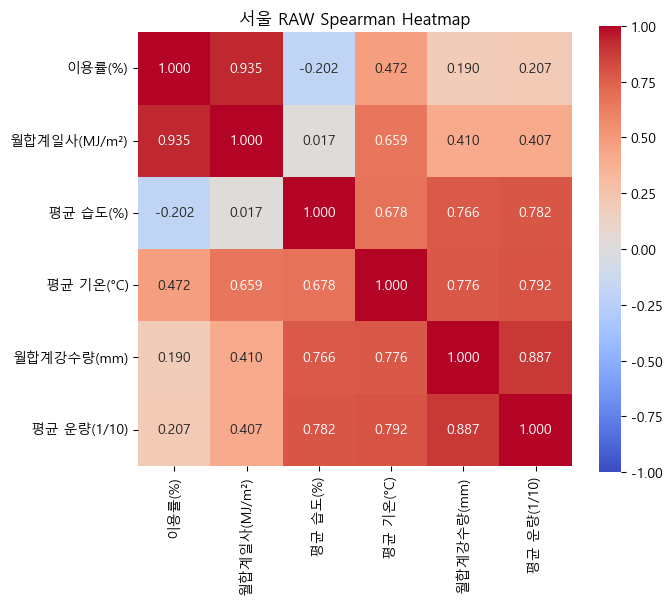

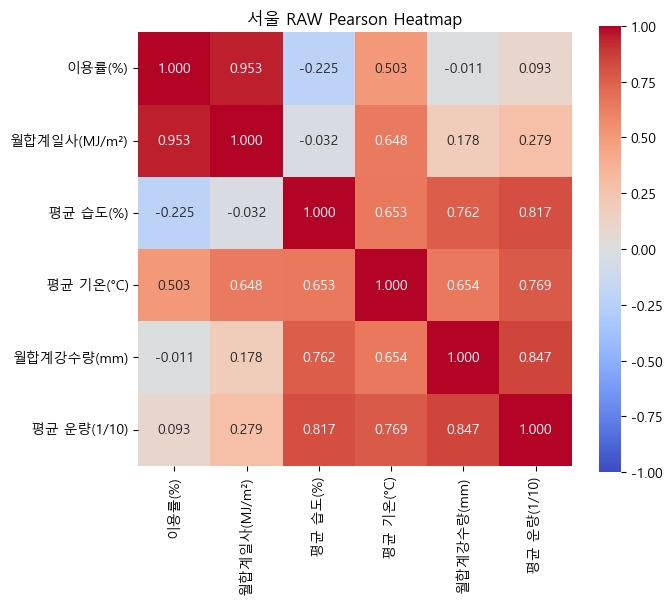

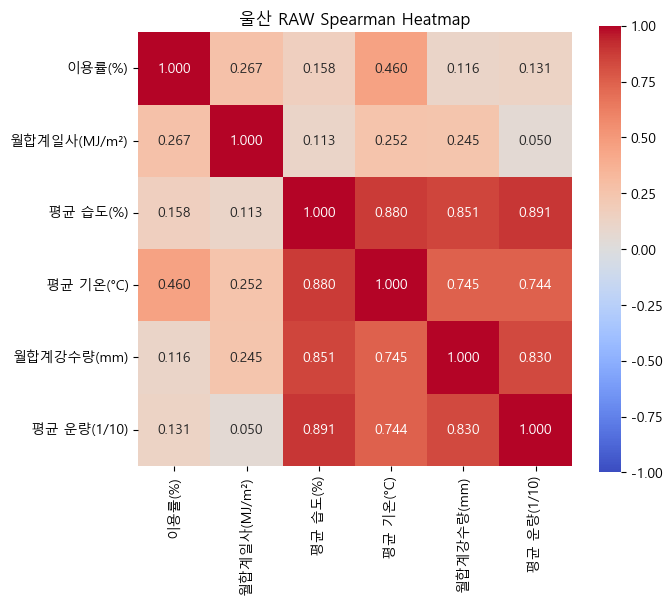

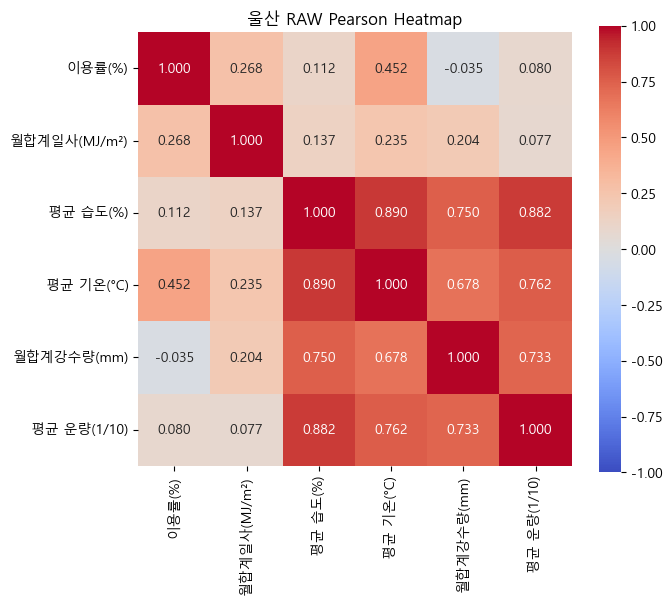


ANOM(월 계절성 제거) 상관분석


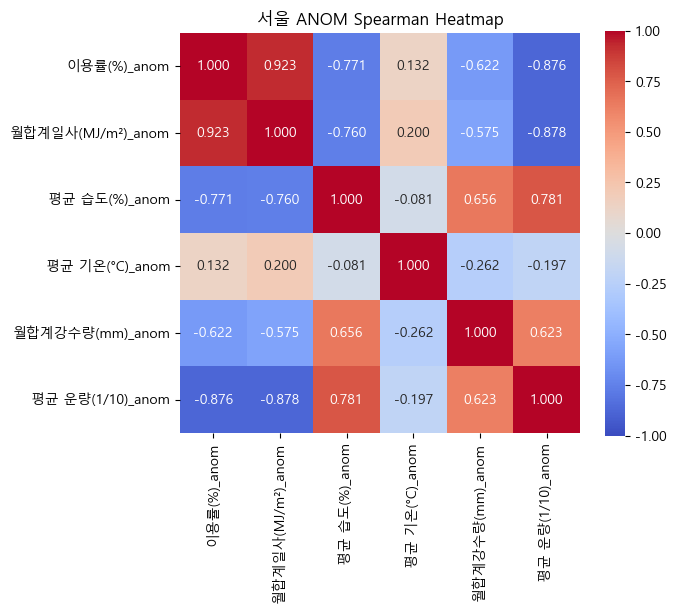

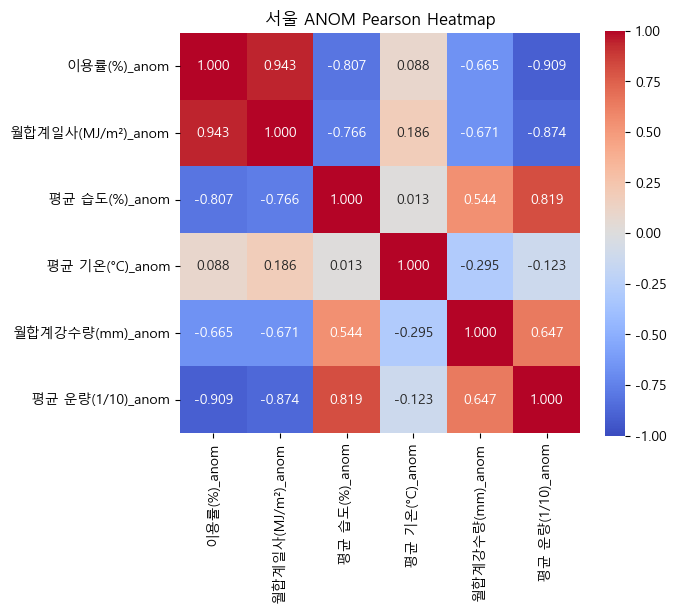

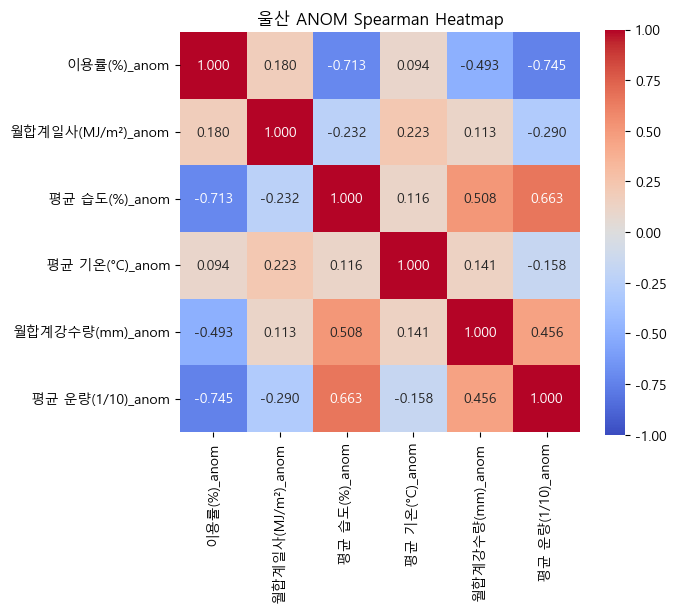

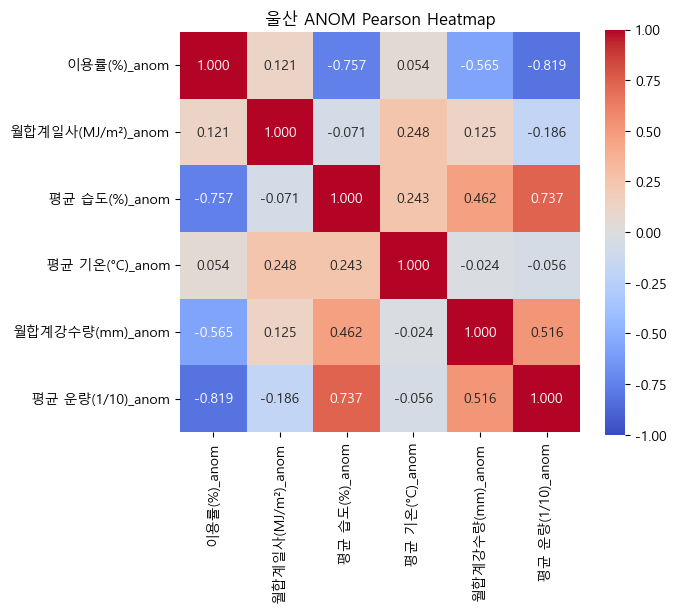


계절별(봄/여름/가을/겨울) RAW vs ANOM Spearman 비교


######## 서울 ########

[봄] 표본수 RAW=12, ANOM=12
  RAW Spearman: {'월합계일사(MJ/m²)': 0.916083916083916, '평균 습도(%)': -0.23776223776223776, '평균 기온(°C)': 0.7622377622377622, '월합계강수량(mm)': -0.09090909090909091, '평균 운량(1/10)': -0.34265734265734266}
  ANOM Spearman: {'월합계일사(MJ/m²)_anom': 0.965034965034965, '평균 습도(%)_anom': -0.7342657342657343, '평균 기온(°C)_anom': 0.46153846153846156, '월합계강수량(mm)_anom': -0.6013986013986014, '평균 운량(1/10)_anom': -0.8391608391608392}

[여름] 표본수 RAW=12, ANOM=12
  RAW Spearman: {'월합계일사(MJ/m²)': 0.9440559440559441, '평균 습도(%)': -0.8741258741258742, '평균 기온(°C)': -0.1888111888111888, '월합계강수량(mm)': -0.8111888111888111, '평균 운량(1/10)': -0.8951048951048951}
  ANOM Spearman: {'월합계일사(MJ/m²)_anom': 0.951048951048951, '평균 습도(%)_anom': -0.8461538461538461, '평균 기온(°C)_anom': 0.7342657342657343, '월합계강수량(mm)_anom': -0.8531468531468531, '평균 운량(1/10)_anom': -0.8181818181818182}

[가을] 표본수 RAW=12, ANOM=12
  RAW Spearman: {'월합계일사(MJ/m²)': 0.9230769230

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 한글 폰트 설정
# =========================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 0) 파일 로드 (인코딩 자동 시도)
# =========================
encodings = ['utf-8', 'utf-8-sig', 'cp949', 'euc-kr']

def read_csv_auto(path):
    last_err = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"✅ 로드 성공: {path} (encoding={enc})")
            return df
        
        except Exception as e:
            last_err = e
    raise ValueError(f"❌ 로드 실패: {path}\n마지막 에러: {last_err}")

WEATHER_PATH = "weather_totals_temp.csv"  # ✅ 여기!
POWER_PATH   = "U통합자료+누적설비용량+누적발전소개수.csv"

print("=" * 70)
print("데이터 로딩 중...")
print("=" * 70)

weather = read_csv_auto(WEATHER_PATH)
power   = read_csv_auto(POWER_PATH)

# =========================
# 1) 기상데이터 전처리 (weather_totals_temp.csv 기준)
# =========================
weather["지역"] = weather["지역"].astype(str).str.strip()

# ✅ weather_totals_temp.csv에 맞춘 변수들
# (너가 보여줬던 컬럼 기준: 월합계일사, 평균습도, 평균기온, 월합계강수량, 평균운량)
weather_vars = [
    "월합계일사(MJ/m²)",
    "평균 습도(%)",
    "평균 기온(°C)",
    "월합계강수량(mm)",
    "평균 운량(1/10)"
]

# 필수컬럼 체크
required_weather_cols = ["지역", "연도", "월"] + weather_vars
missing = [c for c in required_weather_cols if c not in weather.columns]
if missing:
    raise ValueError(
        f"❌ weather_totals_temp.csv에 필수 컬럼이 없습니다: {missing}\n"
        f"현재 컬럼들: {list(weather.columns)}\n"
        f"➡️ 컬럼명이 조금 다르면 그 이름으로 weather_vars를 바꿔줘야 해."
    )

# 숫자화
for c in ["연도", "월"] + weather_vars:
    weather[c] = pd.to_numeric(weather[c], errors="coerce")

# 서울/울산만
weather = weather[weather["지역"].isin(["서울", "울산"])].copy()

# =========================
# 2) 발전데이터 전처리
# =========================
power["구분"] = power["구분"].astype(str).str.strip()

months = [f"{i}월" for i in range(1, 13)]

# long 형태로 변환 (지역/연도/월/발전량/설비용량 등)
power_monthly = []
for _, row in power.iterrows():
    for i, m in enumerate(months, 1):
        power_monthly.append({
            "지역": row["구분"],
            "연도": row["연도"],
            "월": i,
            "발전량": row[m],
            "누적 설치발전소 개수": row.get("누적 설치발전소 개수", np.nan),
            "누적 설비용량(MW)": row.get("누적 설비용량(MW)", np.nan),
        })

power_df = pd.DataFrame(power_monthly)
power_df = power_df[power_df["지역"].isin(["서울", "울산"])].copy()

# 숫자화(콤마 제거 포함)
num_cols = ["발전량", "누적 설치발전소 개수", "누적 설비용량(MW)"]
for c in num_cols:
    power_df[c] = (
        power_df[c].astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
    )
    power_df[c] = pd.to_numeric(power_df[c], errors="coerce")

power_df = power_df.dropna(subset=["발전량", "누적 설비용량(MW)"]).copy()

# =========================
# 3) 이용률 계산
# =========================
def get_days_in_month(year, month):
    import calendar
    return calendar.monthrange(int(year), int(month))[1]

power_df["월_일수"] = power_df.apply(lambda r: get_days_in_month(r["연도"], r["월"]), axis=1)
power_df["이론최대발전량(MWh)"] = power_df["누적 설비용량(MW)"] * power_df["월_일수"] * 24
power_df["이용률(%)"] = (power_df["발전량"] / power_df["이론최대발전량(MWh)"]) * 100

# =========================
# 4) 병합 (지역/연도/월)
# =========================
merged = pd.merge(
    power_df,
    weather,
    on=["지역", "연도", "월"],
    how="inner"
)

print("\n✅ 병합 완료:", merged.shape)
print(merged[["지역","연도","월","이용률(%)"] + weather_vars].head())

# =========================
# 5) 계절 컬럼 추가
# =========================
def season_from_month(m):
    m = int(m)
    if 3 <= m <= 5:  return "봄"
    if 6 <= m <= 8:  return "여름"
    if 9 <= m <= 11: return "가을"
    return "겨울"

merged["계절"] = merged["월"].apply(season_from_month)

target = "이용률(%)"

# =========================
# 6) RAW 상관 + 히트맵
# =========================
def plot_heatmap(df, title, out_png, method="spearman"):
    corr = df[[target] + weather_vars].corr(method=method)
    plt.figure(figsize=(7,6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

print("\n" + "="*70)
print("RAW 상관분석")
print("="*70)

for region in ["서울","울산"]:
    sub = merged[merged["지역"]==region].copy()
    plot_heatmap(sub, f"{region} RAW Spearman Heatmap", f"{region}_RAW_spearman_heatmap.png", method="spearman")
    plot_heatmap(sub, f"{region} RAW Pearson Heatmap", f"{region}_RAW_pearson_heatmap.png", method="pearson")

# =========================
# 7) ANOM(월 계절성 제거) 상관 + 히트맵
#    - (지역,월) 평균을 빼서 anomaly 생성
# =========================
anom = merged.copy()

cols_for_anom = [target] + weather_vars
for c in cols_for_anom:
    anom[c + "_anom"] = anom[c] - anom.groupby(["지역","월"])[c].transform("mean")

target_a = target + "_anom"
weather_a = [v + "_anom" for v in weather_vars]

def plot_heatmap_anom(df, title, out_png, method="spearman"):
    corr = df[[target_a] + weather_a].corr(method=method)
    plt.figure(figsize=(7,6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

print("\n" + "="*70)
print("ANOM(월 계절성 제거) 상관분석")
print("="*70)

for region in ["서울","울산"]:
    sub = anom[anom["지역"]==region].copy()
    plot_heatmap_anom(sub, f"{region} ANOM Spearman Heatmap", f"{region}_ANOM_spearman_heatmap.png", method="spearman")
    plot_heatmap_anom(sub, f"{region} ANOM Pearson Heatmap", f"{region}_ANOM_pearson_heatmap.png", method="pearson")

# =========================
# 8) 계절별(봄/여름/가을/겨울) RAW vs ANOM Spearman 비교(텍스트 출력)
# =========================
print("\n" + "="*70)
print("계절별(봄/여름/가을/겨울) RAW vs ANOM Spearman 비교")
print("="*70)

seasons = ["봄","여름","가을","겨울"]
for region in ["서울","울산"]:
    print(f"\n\n######## {region} ########")
    for s in seasons:
        raw_sub  = merged[(merged["지역"]==region) & (merged["계절"]==s)].copy()
        anom_sub = anom[(anom["지역"]==region) & (anom["계절"]==s)].copy()

        print(f"\n[{s}] 표본수 RAW={len(raw_sub)}, ANOM={len(anom_sub)}")

        if len(raw_sub) >= 3:
            r_raw = raw_sub[[target] + weather_vars].corr(method="spearman").iloc[0,1:]
            print("  RAW Spearman:", r_raw.to_dict())
        else:
            print("  RAW: 표본 부족")

        if len(anom_sub) >= 3:
            r_anom = anom_sub[[target_a] + weather_a].corr(method="spearman").iloc[0,1:]
            print("  ANOM Spearman:", r_anom.to_dict())
        else:
            print("  ANOM: 표본 부족")

print("\n✅ 완료! (RAW/ANOM 히트맵 PNG 저장 + 계절별 비교 출력)")
